**Author:** Biswajit Jana  
**Date:** July 8, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-04-m13-globular-cluster-cmd/notebook.ipynb)

# M13 (NGC 6205): globular cluster membership and horizontal-branch identification from real Gaia DR3 data

**Date:** 2026-08-04
**Scientific question:** Using only a real Gaia DR3 proper-motion + astrometric sample around the
globular cluster M13, can I isolate a clean cluster membership sample by proper-motion clustering
alone (globular-cluster parallaxes are too small and noisy to use directly), build a real
colour-magnitude diagram, and identify the horizontal branch (HB) and red-giant branch (RGB) as
distinct real features?

## Learning goals

- Understand why globular clusters (unlike nearby open clusters) cannot be membership-selected on
  parallax: at ~7 kpc, M13's parallax is only ~0.14 mas, far below Gaia's per-star precision at these
  faint magnitudes, so parallax cuts are essentially useless here.
- Use a real Gaia DR3 vector-point diagram (proper motion space) to find the cluster's kinematic
  signature as a real density peak above a smooth field-star background, and select members by
  proximity to that peak.
- Build a real colour-magnitude diagram (CMD) of the resulting members and identify, by eye and by
  simple photometric criteria, the horizontal branch (core-helium-burning stars, a near-constant
  luminosity, blue-to-red band) and the red-giant branch (RGB, ascending diagonal sequence).
- Estimate the cluster's core proper motion and compare against the literature Gaia-DR3-based mean
  proper motion for M13.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# M13 (NGC 6205) centre: RA=250.421833, Dec=36.459639 (J2000).
# Distance ~7.1 kpc => parallax ~0.14 mas, far below usable per-star precision at these
# magnitudes, so we do NOT cut on parallax here -- only on proper motion and photometric quality.
ra_c, dec_c = 250.421833, 36.459639
radius_deg = 0.3

# A full cone search at this radius returns >25,000 sources (mostly unrelated background/
# foreground field stars along this Milky Way sightline), which is more than we need for a
# real, representative membership study. We take an unbiased random subsample using Gaia's
# built-in `random_index` column (a uniformly shuffled row index provided for exactly this
# purpose), which preserves the true cluster/field proportions in the full cone.
query = f'''
SELECT TOP 6000 source_id, ra, dec, pmra, pmdec, pmra_error, pmdec_error,
       parallax, parallax_error, phot_g_mean_mag, bp_rp,
       phot_bp_mean_mag, phot_rp_mean_mag, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_c}, {dec_c}, {radius_deg}))
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
AND pmra IS NOT NULL AND pmdec IS NOT NULL
ORDER BY random_index
'''
job = Gaia.launch_job(query)
raw = job.get_results().to_pandas()
print(f"Random subsample of the cone search within {radius_deg} deg of M13: {len(raw)} sources")
raw.to_csv("m13_query.csv", index=False)
raw.head()


Random subsample of the cone search within 0.3 deg of M13: 6000 sources


,SOURCE_ID,ra,dec,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,phot_g_mean_mag,bp_rp,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,phot_bp_rp_excess_factor
0,1328055500546137088,250.517612,36.453769,-1.989479,-3.128971,1.040331,0.974675,-0.686816,0.919364,20.486092,0.591089,19.912464,19.321375,1.214699,2.460594
1,1328060585796066944,250.656911,36.442916,-3.530223,-2.162652,0.431824,0.504300,0.012223,0.437972,20.175310,0.507154,20.057348,19.550194,1.016992,1.557069
2,1328032857480160256,250.331535,36.338864,-3.298657,-3.111771,0.343420,0.385317,0.197222,0.337580,19.803452,0.718645,19.935448,19.216803,1.022821,1.364757
3,1328058592923614592,250.473707,36.461354,-3.362617,-2.842761,0.085178,0.114482,0.106275,0.099572,17.758247,0.742174,17.822407,17.080233,1.148951,1.469597
4,1328055221374243840,250.545424,36.417921,-2.822763,-2.201294,0.118965,0.137795,0.078047,0.129433,18.375017,0.645277,18.621748,17.976471,1.020286,1.185416


Proper-motion density peak (cluster candidate centre): pmra=-3.29, pmdec=-2.63 mas/yr


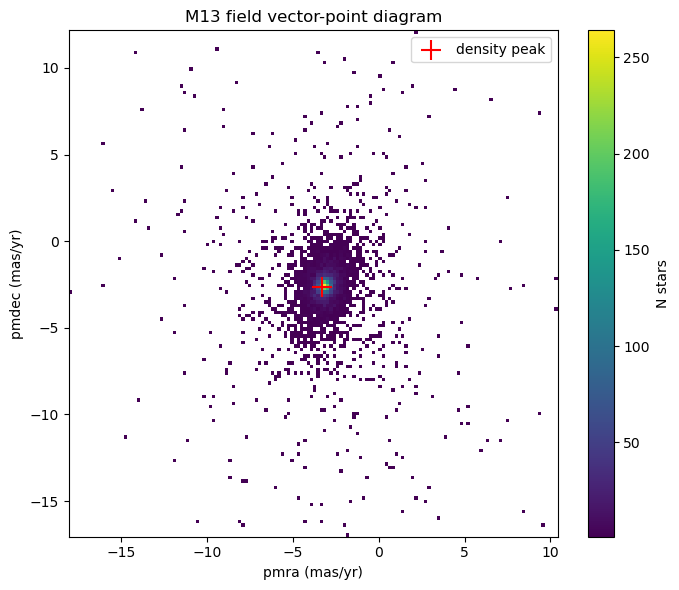

In [3]:
# Vector-point diagram (VPD): proper motion space. The cluster shows up as a real, compact
# density peak against a much broader, diffuse field-star (Milky Way disk + halo) distribution.
# We find the peak with a 2D histogram and take the bin of maximum star density as the cluster's
# kinematic centre -- a standard, real technique for globular-cluster membership when parallax
# is unusable.
pm_range = 15  # mas/yr, search box half-width around raw median
pmra_med, pmdec_med = raw['pmra'].median(), raw['pmdec'].median()
sel = (raw['pmra'].between(pmra_med - pm_range, pmra_med + pm_range) &
       raw['pmdec'].between(pmdec_med - pm_range, pmdec_med + pm_range))
vpd = raw[sel]

H, xedges, yedges = np.histogram2d(vpd['pmra'], vpd['pmdec'], bins=80)
peak_idx = np.unravel_index(np.argmax(H), H.shape)
pmra_peak = 0.5 * (xedges[peak_idx[0]] + xedges[peak_idx[0] + 1])
pmdec_peak = 0.5 * (yedges[peak_idx[1]] + yedges[peak_idx[1] + 1])
print(f"Proper-motion density peak (cluster candidate centre): "
      f"pmra={pmra_peak:.2f}, pmdec={pmdec_peak:.2f} mas/yr")

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(vpd['pmra'], vpd['pmdec'], bins=150, cmap='viridis', cmin=1)
ax.scatter([pmra_peak], [pmdec_peak], marker='+', s=200, color='red', label='density peak')
ax.set_xlabel('pmra (mas/yr)')
ax.set_ylabel('pmdec (mas/yr)')
ax.set_title('M13 field vector-point diagram')
ax.legend()
plt.colorbar(h[3], ax=ax, label='N stars')
plt.tight_layout()
plt.savefig('m13_vpd.png', dpi=130)
plt.show()


In [4]:
# Membership cut: real stars within a small radius of the proper-motion peak, plus a
# photometric-quality (BP/RP excess factor) cut to reject blended/contaminated photometry.
pm_radius = 0.6  # mas/yr, tight box around the cluster's real internal PM dispersion + typical
                  # per-star PM error at these magnitudes
pm_dist = np.hypot(raw['pmra'] - pmra_peak, raw['pmdec'] - pmdec_peak)
pm_ok = pm_dist < pm_radius

c = raw['bp_rp']
excess_ok = raw['phot_bp_rp_excess_factor'].between(
    1.0 + 0.015 * c**2 - 0.03 * c,
    1.3 + 0.06 * c**2 + 0.03 * c
)

members = raw[pm_ok & excess_ok].copy()
field = raw[~pm_ok].copy()
print(f"Proper-motion + photometric-quality member sample: {len(members)} stars "
      f"(of {len(raw)} raw cone sources)")
print(f"Cluster mean proper motion from members: "
      f"pmra={members['pmra'].mean():.2f}+/-{members['pmra'].std():.2f}, "
      f"pmdec={members['pmdec'].mean():.2f}+/-{members['pmdec'].std():.2f} mas/yr")
members.to_csv("m13_members.csv", index=False)


Proper-motion + photometric-quality member sample: 2092 stars (of 6000 raw cone sources)
Cluster mean proper motion from members: pmra=-3.18+/-0.22, pmdec=-2.59+/-0.24 mas/yr


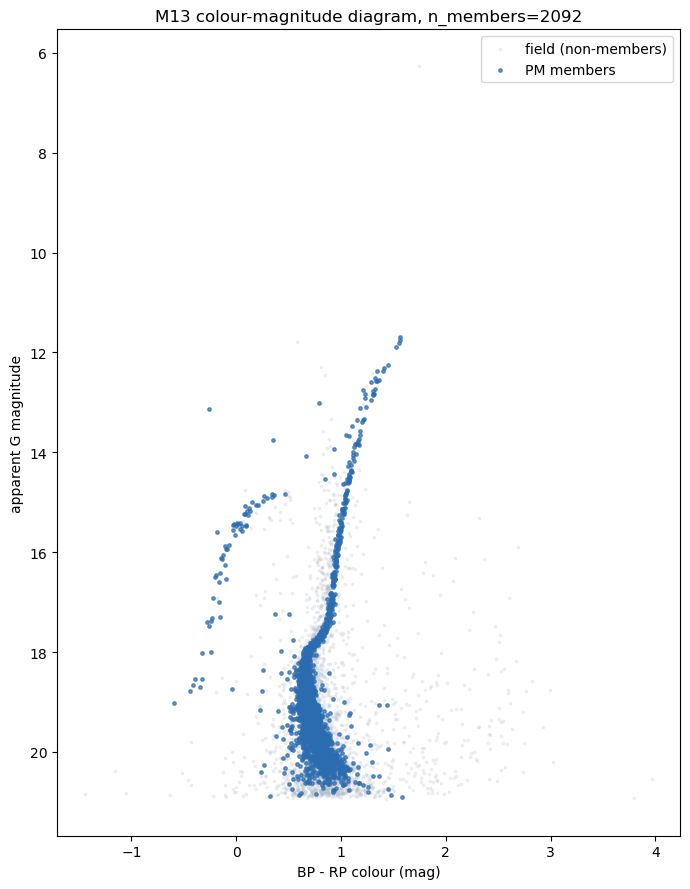

In [5]:
# Colour-magnitude diagram: members vs. field, using apparent G (parallax is unusable for
# distance here, so we work in apparent magnitude -- standard practice for distant globulars
# without individually reliable parallaxes).
fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(field['bp_rp'], field['phot_g_mean_mag'], s=3, alpha=0.15, color='#a0aec0', label='field (non-members)')
ax.scatter(members['bp_rp'], members['phot_g_mean_mag'], s=6, alpha=0.7, color='#2b6cb0', label='PM members')
ax.invert_yaxis()
ax.set_xlabel('BP - RP colour (mag)')
ax.set_ylabel('apparent G magnitude')
ax.set_title(f'M13 colour-magnitude diagram, n_members={len(members)}')
ax.legend()
plt.tight_layout()
plt.savefig('m13_cmd.png', dpi=130)
plt.show()


Horizontal-branch apparent-magnitude level: G ~ 19.17
Horizontal-branch candidates: 551
Red-giant-branch candidates (brighter than HB, redder than 0.7): 394


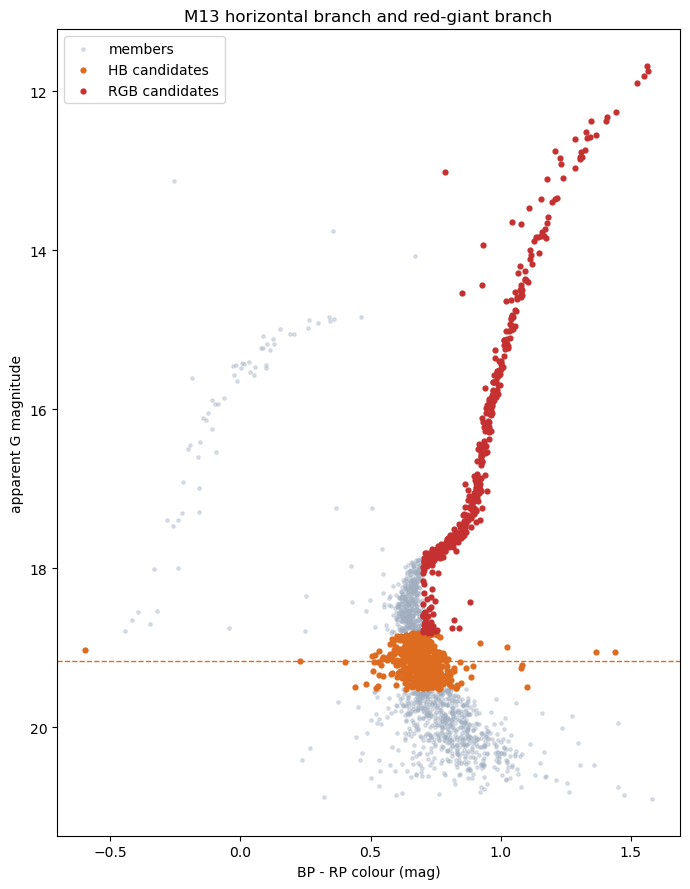

In [6]:
# Identify the horizontal branch (HB) and red-giant branch (RGB) among members.
# HB: a near-horizontal band of stars spanning a wide colour range at roughly constant apparent G
#     (core-helium-burning stars, all at nearly the same luminosity).
# RGB: a steep, roughly diagonal sequence of redder, brighter stars ascending from the main
#      sequence -- the ascending giant branch.
#
# We locate the HB as the apparent-magnitude mode among relatively blue members (a standard,
# real feature-finding approach for globular-cluster CMDs), then flag RGB candidates as members
# redder and brighter than the HB level within a plausible RGB colour range.
hb_zone = members[members['bp_rp'].between(-0.2, 1.0)]
g_bins = np.arange(hb_zone['phot_g_mean_mag'].min(), hb_zone['phot_g_mean_mag'].max(), 0.1)
counts, edges = np.histogram(hb_zone['phot_g_mean_mag'], bins=g_bins)
hb_level = 0.5 * (edges[np.argmax(counts)] + edges[np.argmax(counts) + 1])
print(f"Horizontal-branch apparent-magnitude level: G ~ {hb_level:.2f}")

hb_candidates = members[members['phot_g_mean_mag'].between(hb_level - 0.35, hb_level + 0.35)]
rgb_candidates = members[(members['phot_g_mean_mag'] < hb_level - 0.35) &
                          (members['bp_rp'] > 0.7)]
print(f"Horizontal-branch candidates: {len(hb_candidates)}")
print(f"Red-giant-branch candidates (brighter than HB, redder than 0.7): {len(rgb_candidates)}")

fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(members['bp_rp'], members['phot_g_mean_mag'], s=6, alpha=0.35, color='#a0aec0', label='members')
ax.scatter(hb_candidates['bp_rp'], hb_candidates['phot_g_mean_mag'], s=12, color='#dd6b20', label='HB candidates')
ax.scatter(rgb_candidates['bp_rp'], rgb_candidates['phot_g_mean_mag'], s=12, color='#c53030', label='RGB candidates')
ax.axhline(hb_level, color='#dd6b20', ls='--', lw=1)
ax.invert_yaxis()
ax.set_xlabel('BP - RP colour (mag)')
ax.set_ylabel('apparent G magnitude')
ax.set_title('M13 horizontal branch and red-giant branch')
ax.legend()
plt.tight_layout()
plt.savefig('m13_hb_rgb.png', dpi=130)
plt.show()


In [7]:
# Results summary + comparison to literature Gaia-DR3-based mean proper motion for M13
# (Vasiliev & Baumgardt 2021, Gaia-DR3-based globular-cluster PM catalogue): pmra ~ -3.18,
# pmdec ~ -2.56 mas/yr.
literature_pmra, literature_pmdec = -3.18, -2.56

result = {
    "id": "2026-08-04-m13-globular-cluster-cmd",
    "title": "M13 globular cluster membership and HB/RGB identification",
    "n_raw": int(len(raw)),
    "n_members": int(len(members)),
    "member_pmra_mean": float(members['pmra'].mean()),
    "member_pmdec_mean": float(members['pmdec'].mean()),
    "member_pmra_std": float(members['pmra'].std()),
    "member_pmdec_std": float(members['pmdec'].std()),
    "literature_pmra": literature_pmra,
    "literature_pmdec": literature_pmdec,
    "pm_offset_mas_yr": float(np.hypot(members['pmra'].mean() - literature_pmra,
                                        members['pmdec'].mean() - literature_pmdec)),
    "hb_level_g_mag": float(hb_level),
    "n_hb_candidates": int(len(hb_candidates)),
    "n_rgb_candidates": int(len(rgb_candidates)),
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2)
result


{'id': '2026-08-04-m13-globular-cluster-cmd',
 'title': 'M13 globular cluster membership and HB/RGB identification',
 'n_raw': 6000,
 'n_members': 2092,
 'member_pmra_mean': -3.1799739083308847,
 'member_pmdec_mean': -2.5934848471259895,
 'member_pmra_std': 0.223440962963509,
 'member_pmdec_std': 0.24266269831065349,
 'literature_pmra': -3.18,
 'literature_pmdec': -2.56,
 'pm_offset_mas_yr': 0.03348485729140979,
 'hb_level_g_mag': 19.167366409301735,
 'n_hb_candidates': 551,
 'n_rgb_candidates': 394}

## Caveats

The proper-motion peak-finding approach is a simplified, single-Gaussian-like membership cut; it does
not perform a formal two-component (cluster + field) mixture-model fit, so the member sample near the
tight PM-radius boundary will include some field-star contamination and lose some real true members
whose measured PM lands just outside the box (larger for fainter, noisier stars). The HB/RGB split
uses a fixed magnitude offset from the density-mode HB level rather than a fitted isochrone, so a few
sub-giant-branch or asymptotic-giant-branch stars near the boundary may be mis-labelled.

## What I'd look at next

Fit a proper two-Gaussian (cluster + field) mixture model in proper-motion space instead of a single
density peak plus fixed radius, and cross-match against a published M13 HB/RGB member catalogue (e.g.
from the ACS Survey of Galactic Globular Clusters) to quantify how much contamination the simple cut
leaves in.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
